# ANU - TP4 - Approximation spectrale

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## I - Méthode de la puissance

Cette première partie propose d'implémenter la méthode de la puissance, d'abord afin de visualiser le taux de convergence sur une petite matrice de taille 2 x 2, et ensuite de l'implémenter sur une matrice de taille quelconque.

Pour $A\in M_n(\mathbb{C})$ et $x_0\in \mathbb{C}^n$, la méthode de la puissance consiste à calculer les suites $\nu\in \mathbb{C}^{\mathbb{N}}$ et $x\in (\mathbb{C}^n)^\mathbf{N}$ suivantes :  
$$
\nu_k = \langle x_k,Ax_k\rangle,\quad 
x_{k+1} = \dfrac{Ax_k}{\|Ax_k\|_2}, \quad k\geq 0.
$$


### 1 - Observation du taux de convergence

On s'intéresse à la matrice 2 x 2 suivante:

$$A = \begin{bmatrix}
        1 & 2 \\
        2 & 1
       \end{bmatrix}$$
       
**Q1 -** Déterminer la plus grande valeur propre de $A$ (en module) et la seconde plus grande (donc la plus petite en module ici). Implémenter la méthode de la puissance et observer le taux de convergence sur cette matrice.

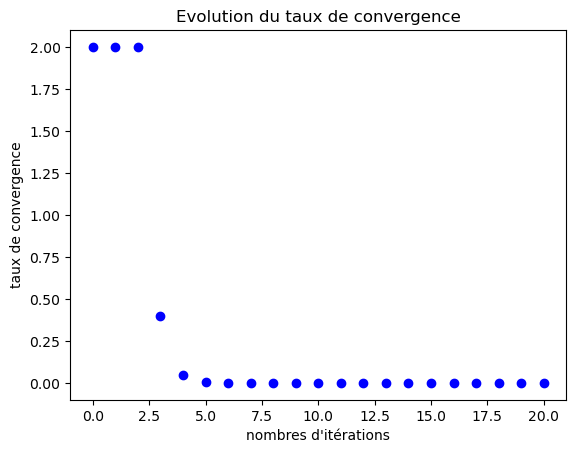

[2, 2, 2, 0.40000000000000036, 0.048780487804878536, 0.005479452054794276, 0.0006095702529709257, 6.773920406377698e-05, 7.526691530479468e-06, 8.363004577738309e-07, 9.29222903067739e-08, 1.0324698873631633e-08, 1.147188566363866e-09, 1.2746603772484377e-10, 1.4162893080538197e-11, 1.573852159708622e-12, 1.7497114868092467e-13, 1.9539925233402755e-14, 2.220446049250313e-15, 0.0, 0.0] [array([1, 0]), array([0.4472136 , 0.89442719]), array([0.78086881, 0.62469505]), array([0.6804511 , 0.73279349]), array([0.71578195, 0.69832385]), array([0.70419091, 0.71001067]), array([0.70807608, 0.70613615]), array([0.70678338, 0.70743003]), array([0.70721455, 0.706999  ]), array([0.70707086, 0.70714271]), array([0.70711876, 0.70709481]), array([0.70710279, 0.70711077]), array([0.70710811, 0.70710545]), array([0.70710634, 0.70710722]), array([0.70710693, 0.70710663]), array([0.70710673, 0.70710683]), array([0.7071068 , 0.70710676]), array([0.70710678, 0.70710679]), array([0.70710678, 0.70710678]), ar

In [26]:
vpmin=-1
vpmax=3
n=20
x_0=np.array([1,0])
A=np.array([[1,2],[2,1]])
x=[x_0]
#np.linealg.norm(np.array([-1,1]-x_0))
v=[np.dot(x_0,np.dot(A,x_0))]
tcvrg=[abs(v[0]-3)]
for i in range(n):
    x.append((np.dot(A,x[len(x)-1]))/(np.linalg.norm(np.dot(A,x[len(x)-1]))))
    v.append(np.dot(x[i],np.dot(A,x[i])))
    tcvrg.append(abs(v[i]-3))
plt.plot(np.arange(0,21),tcvrg,'bo')
plt.xlabel("nombres d'itérations")
plt.ylabel("taux de convergence")
plt.title("Evolution du taux de convergence")
plt.show()
print(tcvrg,x)
    



### 2 - Méthode de la puissance pour une matrice symétrique de taille quelconque

Pour une matrice symétrique réelle $A$ de taille $d \times d$ admettant pour valeurs propres $\lambda_1,\cdots,\lambda_d$ telles que $|\lambda_1|>\cdots>|\lambda_d|$, on peut adapter la méthode de la puissance afin d'en extraire toutes les valeurs et vecteurs propres (NB: La base de vecteurs propres est orthogonale et les valeurs propres sont toutes réelles). Pour cela, on suit les étapes suivantes:

- On détermine d'abord la plus grande valeur propre (en module) $\lambda_1$ ainsi qu'un vecteur propre $v_1$.
- On applique la méthode de la puissance à la matrice $\tilde{A}_1 = A - \lambda_1v_1v_1^*$, cette matrice admet pour valeurs propres $0,\lambda_2,\cdots,\lambda_d$, donc on va extraire $\lambda_2$ et $v_2$ comme vecteur propre associé.
- On applique de nouveau la méthode de la puissance à la matrice $\tilde{A}_2 = A - \lambda_1v_1v_1^* - \lambda_2v_2v_2^*$ pour extraire $\lambda_3$ et $v_3$.
- $\vdots$
- On applique la méthode de la puissance à la matrice $\tilde{A}_k = A - (\lambda_1v_1v_1^* + \cdots + \lambda_kv_kv_k^*)$ pour extraire $\lambda_{k+1}$ et $v_{k+1}$.

**Q2 -** Coder la méthode de la puissance et la tester sur une matrice symétrique quelconque (par exemple de taille 10 x 10), comparer avec la fonction $\verb|np.linalg.eigh|$

In [55]:
A=np.eye(10)
#print(A)

l=[]
#x_0=np.array([1,1,1,1,1,1,1,1,1,1])
x_0=np.array([0,0,0,0,0,0,0,0,0,0])
x=[x_0]
#print(len(x_0),len(A))
v=[np.dot(x_0,np.dot(A,x_0))]
#tcvrg=[abs(v[0]-3)]
for k in range(len(A)):
    x_0=np.array([1,0,0,0,0,0,0,0,0,0])
    x=[x_0]
    v=[np.dot(x_0,np.dot(A,x_0))]
    #tcvrg=[abs(v[0]-3)]
    i=1
    while i<10:
        x.append((np.dot(A,x[len(x)-1]))/(np.linalg.norm(np.dot(A,x[len(x)-1]))))
        v.append(np.dot(x[i-1],np.dot(A,x[i-1])))
        #tcvrg.append(abs(v[i]-3))
        i=i+1
        #print(i,tcvrg[len(tcvrg)-1])
    l.append((x[len(x)-1],v[len(v)-1]))
    l[len(l)-1]=(l[len(l)-1][0][np.newaxis, :],l[len(l)-1][1])
    A=A-l[len(l)-1][1]*np.dot(l[len(l)-1][0].T,l[len(l)-1][0])
    print(A,l[len(l)-1][0],l[len(l)-1][0].T,np.dot(l[len(l)-1][0].T,l[len(l)-1][0]))
print(l)
        
    


[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]] [[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]] [[1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]] [[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]
[[nan nan nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan nan nan nan nan]
 [nan nan nan nan nan nan na

/tmp/ipykernel_6207/2324283259.py:18: RuntimeWarning: invalid value encountered in divide
  x.append((np.dot(A,x[len(x)-1]))/(np.linalg.norm(np.dot(A,x[len(x)-1]))))


## II - Méthode QR

Dans cette seconde partie, on s'intéresse à l'application de la méthode QR pour la recherche de valeurs propres. Il est également possible (cf. théormème 80 du cours, Chapitre 3), de trouver les vecteurs propres. Pour cela, on suit les étapes suivantes:

- On fait la décomposition QR de $A$: $A = Q_0R_0$. On pose $V_0 = Q_0$ et $A_1 = R_0Q_0$.
- On fait la décomposition QR de $A_1$: $A_1 = Q_1R_1$. On pose $V_1 = V_0Q_1$ et $A_2 = R_1Q_1$.
- $\vdots$
- On fait la décomposition QR de $A_k$: $A_{k} = Q_{k}R_{k}$. On pose $V_{k} = V_{k-1}Q_{k}$ et $A_{k+1} = R_kQ_k$.
- On continue avec un nombre assez grand d'itérations.

La diagonale de $(A_k)_{k\in\mathbb{N}}$ converge vers la diagonale des valeurs propres de $A$, la suite $(V_k)_{k\in\mathbb{N}}$ converge vers la liste des vecteurs propres associés $[v_1|\cdots|v_d]$.

**Q3 -** Coder la méthode QR avec recherche de vecteurs propres et la tester sur une matrice symétrique quelconque (par exemple de taille 5 x 5). Pour la décomposition QR, on utilisera la fonction $\verb|np.linalg.qr|$, et pour la vérification, on comparera soit vec la méthode de la puissance, soit la fonction $\verb|np.linalg.eigh|$.

## III - Application: Tenseur de déformation

En mécanique, le tenseur de déformation d'un matériau va représenter la manière dont une contrainte sur ce matériau va le déformer, dans le plan ou dans l'espace. Il est représenté par une matrice de taille 2 x 2 (déformation dans le plan) ou 3 x 3 (déformation dans l'espace). Dans notre application, nous nous concentrerons sur le cas de la dimension 2.

Ainsi, une déformation va avoir des directions principales et, selon ces directions principales, va correspondre à une dilatation. ces directions principales sont données par les vecteurs propres du tenseur, les coefficients de dilatation correspondant aux valeurs propres du tenseur.

Ainsi, un tenseur de déformation en dimension 2 appliqué aux points d'un cercle va donner une ellipse, dont l'orientation est donnée par les vecteurs propres de la matrice 2 x 2, et les rayons par les modules des valeurs propres de la matrice.


$$T_1 = \begin{bmatrix}
        1 & 2 \\
        2 & 1
      \end{bmatrix} , T_2 = \begin{bmatrix}
        1 & 2 \\
        2 & 5
      \end{bmatrix} , T_3 = \begin{bmatrix}
        1 & 2 \\
        2 & 0
      \end{bmatrix}$$
      
**Q4 -** En testant les exemples suivants, appliquer la matrice aux points d'un cercle, afficher le cercle, l'ellipse obtenue, les vecteurs propres sur un même graphique. Calculer les valeurs et vecteurs propres des matrices données en exemple. On utilisera au choix la méthode de la puissance (question Q2) ou la méthode QR (question Q3).